In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("function-trf-titanic.csv",usecols=["Age","Fare","Survived"])

In [3]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [6]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,28.0,23.4500
889,1,26.0,30.0000


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x=df[["Age","Fare"]]
y=df[["Survived"]]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,28.0,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [12]:
y_train

,Survived
331,0
733,0
382,0
704,0
813,0
...,...
106,1
270,0
860,0
435,1


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [42]:
import scipy

print(scipy.__version__)# 

1.17.1


#Age DISTRIBUTION

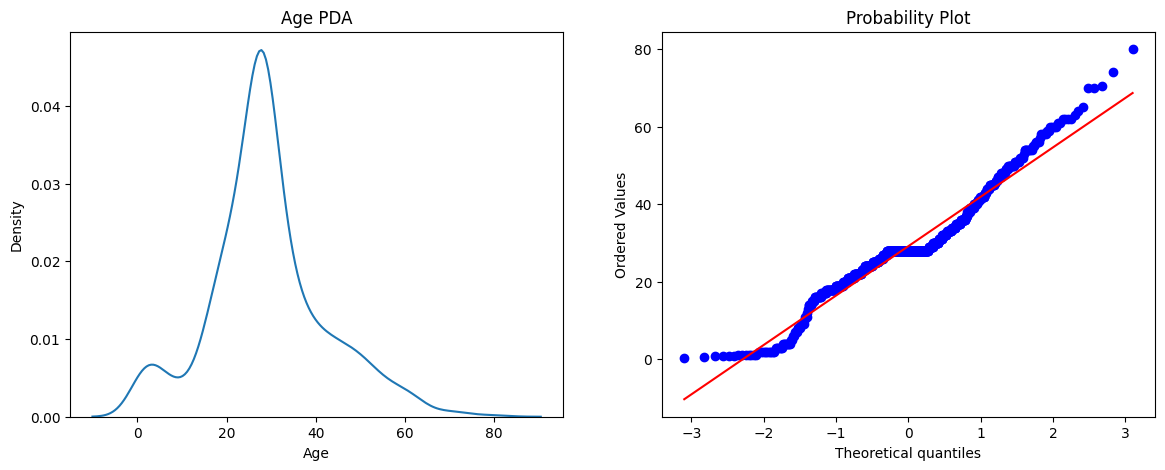

In [14]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,5))
ax[0].set_title("Age PDA")
ax[1].set_title("Age QQ plot")
sns.kdeplot(x_train["Age"],ax=ax[0])
stats.probplot(x_train["Age"],dist="norm",plot=ax[1])

plt.show()


In [ ]:
# ax[1].set_title("Age QQ plot") overwrite ,here 

Text(0.5, 1.0, 'Age QQ plot')

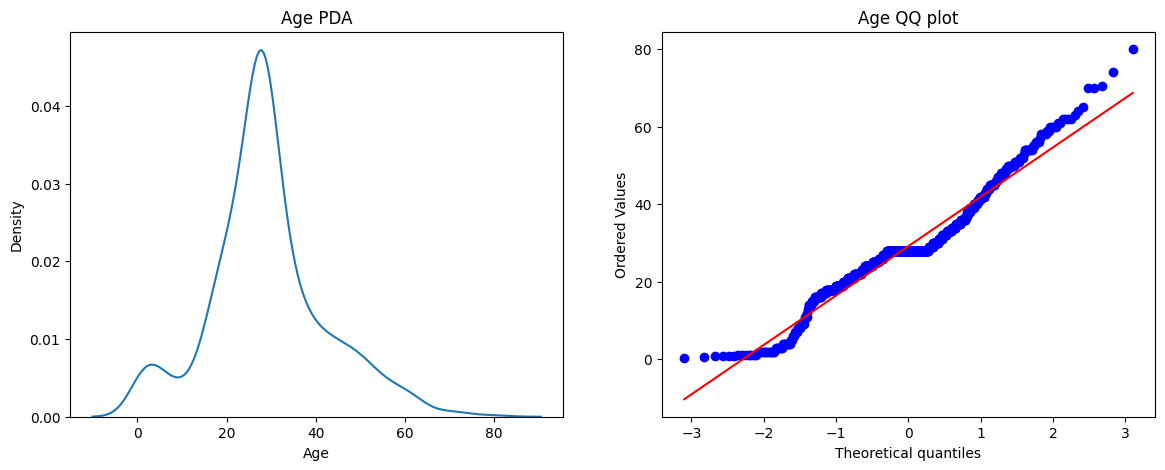

In [15]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,5))
ax[0].set_title("Age PDA")
sns.kdeplot(data=x_train,x="Age",ax=ax[0])
stats.probplot(x_train["Age"],dist="norm",plot=ax[1])
ax[1].set_title("Age QQ plot")

#FARE DISTRIBUTION

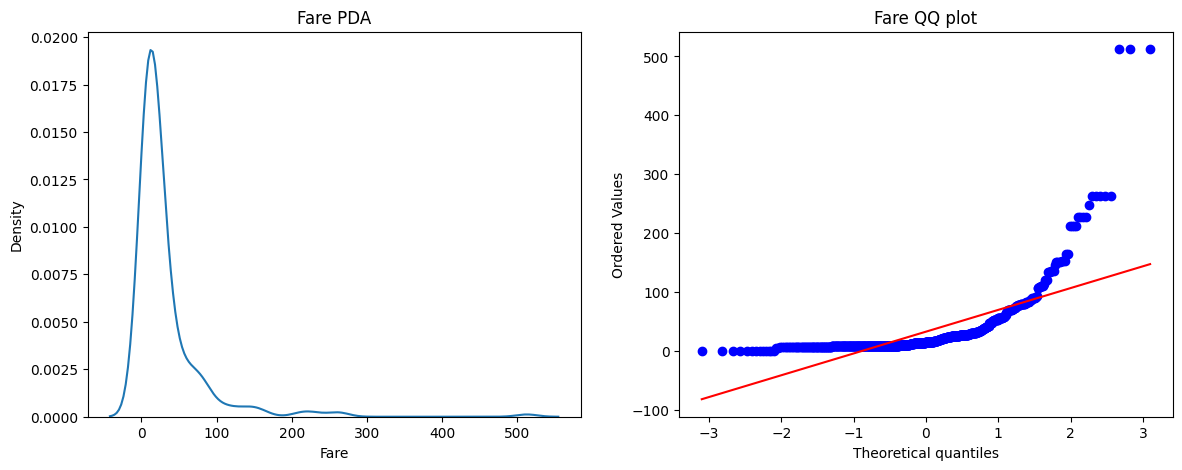

In [17]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,5))
ax[0].set_title("Fare PDA")
sns.kdeplot(data=x_train,x="Fare",ax=ax[0])
stats.probplot(x_train["Fare"],dist="norm",plot=ax[1])
ax[1].set_title("Fare QQ plot")
plt.show()

In [25]:
x_train["Age"].skew() #np.float64(0.43581171974032523)
x_train["Fare"].skew() #np.float64(4.875065571137606)

np.float64(4.875065571137606)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier



In [29]:

lr=LogisticRegression()
dt=DecisionTreeClassifier()

lr.fit(x_train,y_train)
dt.fit(x_train,y_train)

y_pred_lr=lr.predict(x_test)
y_pred_dt=dt.predict(x_test)

print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))



Logistic Regression Accuracy: 0.6480446927374302
Decision Tree Accuracy: 0.6759776536312849


c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [32]:
#WITH FUNCTION TRANSFORMATION

In [34]:
from sklearn.preprocessing import FunctionTransformer

In [ ]:
ft=FunctionTransformer(np.log1p) #log1p(x+1) to handle zero values in feature columns
x_train_ft=ft.fit_transform(x_train)
x_test_ft=ft.transform(x_test)

In [38]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()

In [48]:
lr.fit(x_train_ft,y_train)
dt.fit(x_train_ft,y_train)

y_pred_lr=lr.predict(x_test_ft)
y_pred_dt=dt.predict(x_test_ft)

print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))



Logistic Regression Accuracy: 0.6759776536312849
Decision Tree Accuracy: 0.664804469273743


c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [53]:
# np.log(11)
# np.log(1000)
# np.log(0)

In [54]:
from sklearn.model_selection import cross_val_score

In [57]:
x_transformed=ft.fit_transform(x)
lr=LogisticRegression()
dt=DecisionTreeClassifier()

print("lr",np.mean(cross_val_score(lr,x_transformed,y,cv=10)))
print("dt",np.mean(cross_val_score(dt,x_transformed,y,cv=10)))

c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A 

lr 0.678027465667915
dt 0.6666666666666666


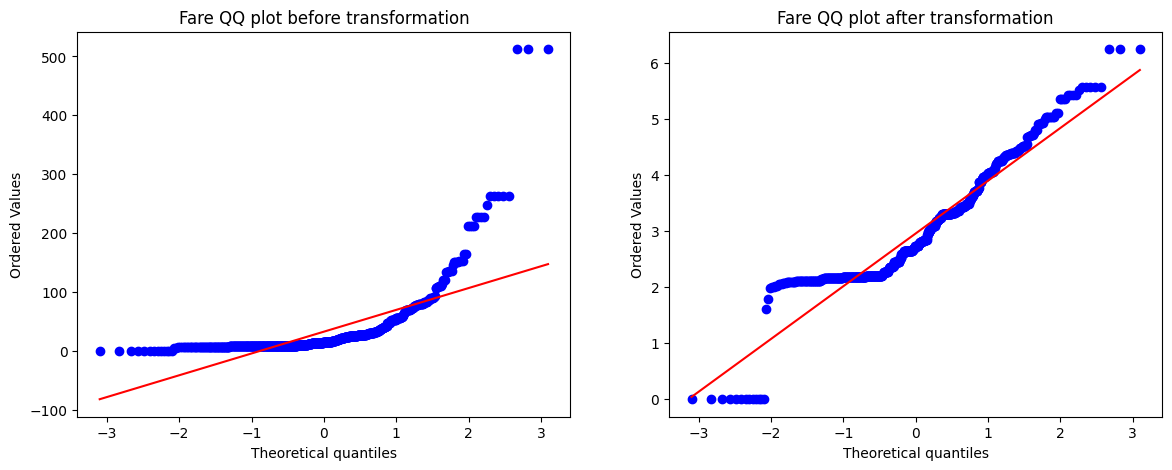

In [61]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,5))
stats.probplot(x_train["Fare"],dist="norm",plot=ax[0])
ax[0].set_title("Fare QQ plot before transformation")
stats.probplot(x_train_ft["Fare"],dist="norm",plot=ax[1])
ax[1].set_title("Fare QQ plot after transformation")
plt.show()

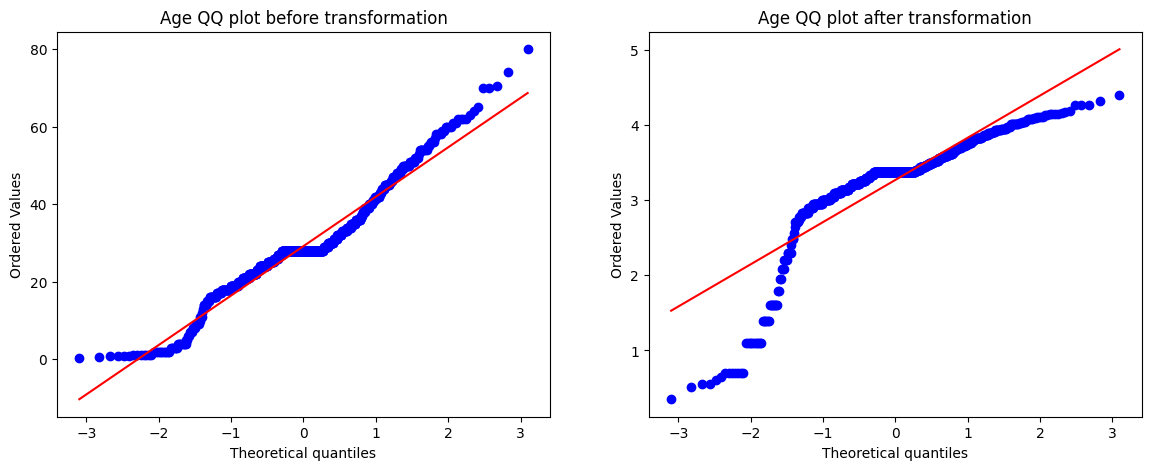

In [63]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,5))

stats.probplot(x_train["Age"],dist="norm",plot=ax[0])
ax[0].set_title("Age QQ plot before transformation")

stats.probplot(x_train_ft["Age"],dist="norm",plot=ax[1])
ax[1].set_title("Age QQ plot after transformation")
plt.show()

#here we see that age before transformation look good so we will kept before age transformer only.

In [64]:
from sklearn.compose import ColumnTransformer

In [66]:
ct=ColumnTransformer([("log",FunctionTransformer(np.log1p),["Fare"])],remainder="passthrough")

x_train_ct=ct.fit_transform(x_train)
x_test_ct=ct.transform(x_test)


In [67]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()


In [69]:
lr.fit(x_train_ct,y_train)
dt.fit(x_train_ct,y_train)

y_pred_lr=lr.predict(x_test_ct)
y_pred_dt=dt.predict(x_test_ct)

print("Logistic Regression Accuracy:",accuracy_score(y_test,y_pred_lr))
print("Decision Tree Accuracy:",accuracy_score(y_test,y_pred_dt))

Logistic Regression Accuracy: 0.6759776536312849
Decision Tree Accuracy: 0.664804469273743


c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [72]:
#cross validation 

In [74]:
x_transformed2=ct.fit_transform(x)
lr=LogisticRegression()
dt=DecisionTreeClassifier()
print("lr",np.mean(cross_val_score(lr,x_transformed2,y,scoring='accuracy',cv=10)))
print("dt",np.mean(cross_val_score(dt,x_transformed2,y,scoring='accuracy',cv=10)))

c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\maner\OneDrive\Desktop\ML Practice\MLenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A 

lr 0.6690137328339576
dt 0.6599625468164794
